In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.2.2
Device          : cpu


In [2]:
BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

jobs_df = pd.read_csv(PROCESSED_DIR / 'stage1b_merged_clean.csv')

print(f"Jobs loaded      : {len(jobs_df):,}")
print(f"Columns          : {list(jobs_df.columns)}")
print(f"\nTarget (cpu_max_peak) stats:")
print(jobs_df['cpu_max_peak'].describe().round(3))
print(f"\nTarget (util_ratio_peak) stats:")
print(jobs_df['util_ratio_peak'].describe().round(3))

Jobs loaded      : 11,644
Columns          : ['job_name', 'plan_cpu_cores', 'task_count', 'cpu_avg_peak', 'cpu_max_peak', 'instance_count', 'cpu_avg_mean', 'cpu_avg_std', 'cpu_avg_max', 'util_ratio_avg', 'util_ratio_peak', 'provisioning_class', 'is_underprovision', 'plan_cpu_per_task', 'instance_to_task_ratio', 'is_multi_task', 'is_large_job', 'size_bucket', 'cpu_size_bucket_encoded']

Target (cpu_max_peak) stats:
count    11644.000
mean         3.279
std          2.969
min          0.020
25%          1.050
50%          2.030
75%          5.332
max         31.000
Name: cpu_max_peak, dtype: float64

Target (util_ratio_peak) stats:
count    11644.000
mean         1.625
std          2.343
min          0.019
25%          0.412
50%          0.868
75%          1.790
max         31.000
Name: util_ratio_peak, dtype: float64


In [3]:
bi_cols = [
    'instance_name', 'task_name', 'job_name', 'task_id',
    'start_time', 'status', 'seq_no', 'total_seq_no',
    'cpu_max', 'cpu_avg', 'mem_max', 'mem_avg'
]

print("Loading batch_instance_corrected.csv — this will take a moment...")
bi = pd.read_csv(PROCESSED_DIR / 'batch_instance_corrected.csv',
                 names=bi_cols, header=0)

bi_terminated = bi[bi['status'] == 'Terminated'].copy()
bi_terminated = bi_terminated.dropna(subset=['cpu_max'])
bi_terminated = bi_terminated.sort_values(['job_name', 'task_name', 'seq_no'])

print(f"Total rows             : {len(bi):,}")
print(f"Terminated rows        : {len(bi_terminated):,}")
print(f"\ncpu_max stats:")
print(bi_terminated['cpu_max'].describe().round(3))

del bi
import gc
gc.collect()
print("\nRaw instance data loaded")

Loading batch_instance_corrected.csv — this will take a moment...
Total rows             : 16,094,656
Terminated rows        : 13,707,854

cpu_max stats:
count    1.370785e+07
mean     1.501000e+00
std      1.285000e+00
min      0.000000e+00
25%      9.200000e-01
50%      1.040000e+00
75%      1.840000e+00
max      3.200000e+01
Name: cpu_max, dtype: float64

Raw instance data loaded


---
## Section 1: Sequence Construction

For each job, we extract the sequence of cpu_max readings ordered by
task_name then seq_no. We use the first 40 readings as input to the LSTM.
The target is the maximum cpu_max value across all remaining readings —
i.e. the peak the job reaches after the first 40 instances.

Jobs with fewer than 15 instances are excluded as there is insufficient
history to make a meaningful prediction.

In [4]:
INPUT_LEN  = 40
MIN_SEQ_LEN = 15

print("Building sequences per job...")

records = []
for job_name, group in bi_terminated.groupby('job_name'):
    seq = group['cpu_max'].values

    if len(seq) < MIN_SEQ_LEN:
        continue

    input_seq = seq[:INPUT_LEN]
    remaining = seq[INPUT_LEN:]

    if len(remaining) == 0:
        target_peak = float(np.max(input_seq))
    else:
        target_peak = float(np.max(remaining))

    records.append({
        'job_name'   : job_name,
        'input_seq'  : input_seq.tolist(),
        'seq_len'    : len(seq),
        'target_peak': target_peak
    })

seq_df = pd.DataFrame(records)
print(f"Jobs with sequences     : {len(seq_df):,}")
print(f"Jobs excluded (<{MIN_SEQ_LEN} inst): {bi_terminated['job_name'].nunique() - len(seq_df):,}")
print(f"\nSequence length stats:")
print(seq_df['seq_len'].describe().round(1))
print(f"\nTarget peak stats:")
print(seq_df['target_peak'].describe().round(3))

Building sequences per job...
Jobs with sequences     : 8,546
Jobs excluded (<15 inst): 3,261

Sequence length stats:
count     8546.0
mean      1211.6
std       3314.7
min         15.0
25%        103.0
50%        510.5
75%        927.0
max      66627.0
Name: seq_len, dtype: float64

Target peak stats:
count    8546.000
mean        3.825
std         2.910
min         0.040
25%         2.000
50%         2.060
75%         6.500
max        30.000
Name: target_peak, dtype: float64


In [5]:
df = jobs_df.merge(seq_df, on='job_name', how='inner')

print(f"Jobs after merge        : {len(df):,}")
print(f"Jobs lost in merge      : {len(jobs_df) - len(df):,}")

print(f"\nProvisioning class distribution:")
total = len(df)
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (df['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>5,} ({count/total*100:.1f}%)")

print(f"\nCorrelation between target_peak and cpu_max_peak:")
print(f"  {df['target_peak'].corr(df['cpu_max_peak']):.4f}")
print(f"\nNote: target_peak is the max of instances AFTER position 40.")
print(f"cpu_max_peak is the global max across all instances.")
print(f"They differ for jobs where the peak occurs in the first 40 instances.")

Jobs after merge        : 8,428
Jobs lost in merge      : 3,216

Provisioning class distribution:
  severely_under      : 2,855 (33.9%)
  under               : 1,568 (18.6%)
  efficient           : 2,033 (24.1%)
  over                : 1,972 (23.4%)

Correlation between target_peak and cpu_max_peak:
  0.9321

Note: target_peak is the max of instances AFTER position 40.
cpu_max_peak is the global max across all instances.
They differ for jobs where the peak occurs in the first 40 instances.


In [6]:
def pad_sequence(seq, length):
    seq = np.array(seq, dtype=np.float32)
    if len(seq) >= length:
        return seq[:length]
    pad = np.zeros(length, dtype=np.float32)
    pad[-len(seq):] = seq
    return pad


X_raw = np.array([pad_sequence(row['input_seq'], INPUT_LEN) for _, row in df.iterrows()])
y_raw = df['target_peak'].values.astype(np.float32)

print(f"X shape : {X_raw.shape}")
print(f"y shape : {y_raw.shape}")
print(f"\nX value range : [{X_raw.min():.3f}, {X_raw.max():.3f}]")
print(f"y value range : [{y_raw.min():.3f}, {y_raw.max():.3f}]")

p95 = np.percentile(y_raw, 95)
print(f"\ny 95th percentile : {p95:.3f}")
print(f"Values above p95  : {(y_raw > p95).sum():,} ({(y_raw > p95).mean()*100:.1f}%)")

y_clipped = np.clip(y_raw, 0, p95).astype(np.float32)
print(f"\nClipped y range : [{y_clipped.min():.3f}, {y_clipped.max():.3f}]")

X shape : (8428, 40)
y shape : (8428,)

X value range : [0.000, 31.000]
y value range : [0.040, 30.000]

y 95th percentile : 8.140
Values above p95  : 412 (4.9%)

Clipped y range : [0.040, 8.140]


In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_clipped, test_size=0.2, random_state=42
)

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train_raw)
X_test  = X_scaler.transform(X_test_raw)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nScaling complete")

Train size : 6,742
Test size  : 1,686

X_train shape : (6742, 40)
X_test shape  : (1686, 40)

Scaling complete


In [8]:
class JobSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(2)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = JobSequenceDataset(X_train, y_train_scaled)
test_dataset  = JobSequenceDataset(X_test,  y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Input shape   : {next(iter(train_loader))[0].shape}")

Train batches : 106
Test batches  : 27
Input shape   : torch.Size([64, 40, 1])


---
## Section 3: LSTM Model

A two-layer LSTM encoder with batch normalisation and a fully connected
head. The model takes the sequence of cpu_max readings as input and
outputs a single scalar — the predicted peak CPU usage.

In [9]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMForecaster, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        self.bn = nn.BatchNorm1d(hidden_size)

        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last    = out[:, -1, :]
        last    = self.bn(last)
        return self.head(last).squeeze(1)


model     = LSTMForecaster(input_size=1, hidden_size=64,
                            num_layers=2, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=False
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters : {n_params:,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.3)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 52,673


In [10]:
EPOCHS   = 60
PATIENCE = 10

train_losses      = []
test_losses       = []
best_test_loss    = float('inf')
best_epoch        = 0
no_improve        = 0
best_state        = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds   = model(X_batch)
            loss    = criterion(preds, y_batch)
            test_loss += loss.item() * len(X_batch)
    test_loss /= len(test_dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch     = epoch + 1
        no_improve     = 0
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS} "
              f"| Train MSE: {train_loss:.4f} "
              f"| Test MSE: {test_loss:.4f} "
              f"| Best: {best_test_loss:.4f} @ epoch {best_epoch}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"\nBest model restored from epoch {best_epoch}")
print(f"Best test MSE : {best_test_loss:.4f}")

Epoch  10/60 | Train MSE: 0.2949 | Test MSE: 0.2982 | Best: 0.2907 @ epoch 9
Epoch  20/60 | Train MSE: 0.2516 | Test MSE: 0.2868 | Best: 0.2383 @ epoch 17
Epoch  30/60 | Train MSE: 0.2358 | Test MSE: 0.2288 | Best: 0.2288 @ epoch 30
Epoch  40/60 | Train MSE: 0.2305 | Test MSE: 0.2297 | Best: 0.2274 @ epoch 39
Epoch  50/60 | Train MSE: 0.2335 | Test MSE: 0.2331 | Best: 0.2220 @ epoch 49
Epoch  60/60 | Train MSE: 0.2280 | Test MSE: 0.2221 | Best: 0.2209 @ epoch 56

Best model restored from epoch 56
Best test MSE : 0.2209


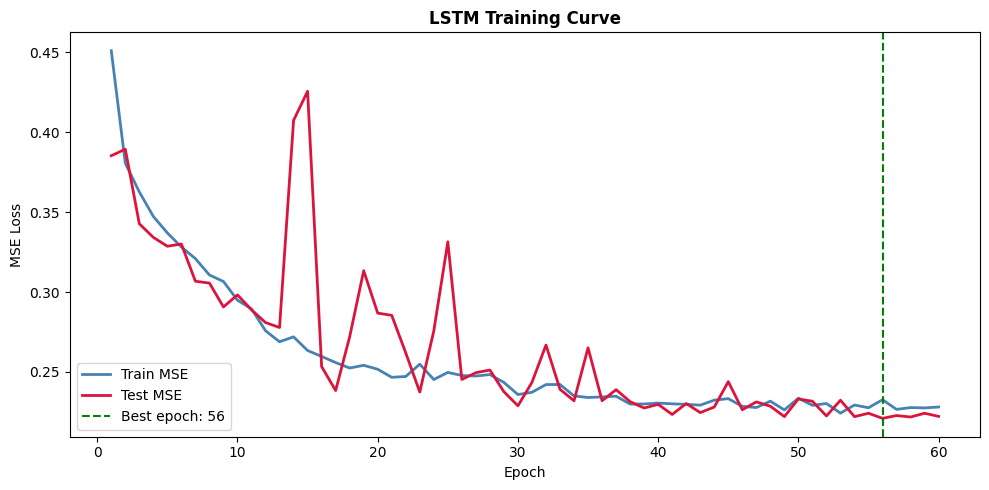

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses)+1), train_losses,
        color='steelblue', linewidth=2, label='Train MSE')
ax.plot(range(1, len(test_losses)+1), test_losses,
        color='crimson', linewidth=2, label='Test MSE')
ax.axvline(best_epoch, color='green', linestyle='--',
           linewidth=1.5, label=f'Best epoch: {best_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Training Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
#Rightsizing Recommendations
model.eval()
preds_scaled = []
actuals      = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        preds_scaled.extend(out.cpu().tolist())
        actuals.extend(y_batch.tolist())

preds_scaled = np.array(preds_scaled)
actuals      = np.array(actuals)

preds_orig = y_scaler.inverse_transform(
    preds_scaled.reshape(-1, 1)
).flatten()
actuals_orig = y_scaler.inverse_transform(
    actuals.reshape(-1, 1)
).flatten()

preds_orig   = np.maximum(preds_orig, 0)
actuals_orig = np.maximum(actuals_orig, 0)

mae  = mean_absolute_error(actuals_orig, preds_orig)
rmse = np.sqrt(mean_squared_error(actuals_orig, preds_orig))
r2   = r2_score(actuals_orig, preds_orig)

print("=" * 50)
print("LSTM EVALUATION RESULTS")
print("=" * 50)
print(f"\nMAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

LSTM EVALUATION RESULTS

MAE  : 0.7359
RMSE : 1.1924
R²   : 0.7787


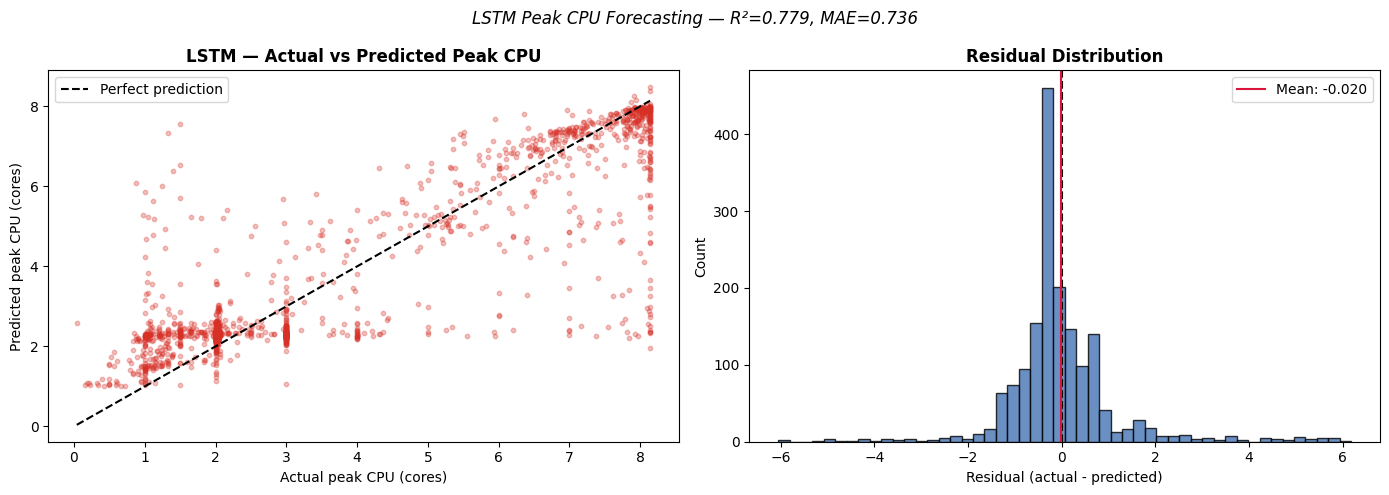

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(actuals_orig, preds_orig, alpha=0.3, s=10, color='#d73027')
axes[0].plot([actuals_orig.min(), actuals_orig.max()],
             [actuals_orig.min(), actuals_orig.max()],
             'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual peak CPU (cores)')
axes[0].set_ylabel('Predicted peak CPU (cores)')
axes[0].set_title('LSTM — Actual vs Predicted Peak CPU', fontweight='bold')
axes[0].legend()

residuals = actuals_orig - preds_orig
axes[1].hist(residuals, bins=50, color='#4575b4', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='crimson', linestyle='-',
                linewidth=1.5, label=f'Mean: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle(f'LSTM Peak CPU Forecasting — R²={r2:.3f}, MAE={mae:.3f}',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

In [15]:
print("=" * 50)
print("RIGHTSIZING RECOMMENDATIONS")
print("=" * 50)

_, X_test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)

test_jobs = df.iloc[X_test_idx].copy().reset_index(drop=True)
test_jobs['predicted_peak']    = preds_orig
test_jobs['recommended_cpu']   = test_jobs['predicted_peak'] * 1.15
test_jobs['recommended_cpu']   = test_jobs.apply(
    lambda r: max(0.3 * r['plan_cpu_cores'],
                  min(3.0 * r['plan_cpu_cores'], r['recommended_cpu'])),
    axis=1
)
test_jobs['rightsizing_ratio'] = (
    test_jobs['recommended_cpu'] / test_jobs['plan_cpu_cores']
)

def classify_action(ratio):
    if ratio > 1.05:
        return 'increase'
    elif ratio < 0.95:
        return 'decrease'
    else:
        return 'maintain'

test_jobs['action'] = test_jobs['rightsizing_ratio'].apply(classify_action)

print(f"\nAction distribution:")
print(test_jobs['action'].value_counts())
print(f"\nRightsizing ratio stats:")
print(test_jobs['rightsizing_ratio'].describe().round(3))
print(f"\nSample recommendations:")
print(test_jobs[['job_name', 'plan_cpu_cores', 'cpu_max_peak',
                  'predicted_peak', 'recommended_cpu',
                  'rightsizing_ratio', 'action']].head(10).round(3).to_string(index=False))

output_path = BASE_DIR / 'results' / 'lstm_v3_recommendations.csv'
output_path.parent.mkdir(exist_ok=True)
test_jobs.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

RIGHTSIZING RECOMMENDATIONS

Action distribution:
action
increase    954
decrease    695
maintain     37
Name: count, dtype: int64

Rightsizing ratio stats:
count    1686.000
mean        1.458
std         0.974
min         0.300
25%         0.583
50%         1.190
75%         2.496
max         3.000
Name: rightsizing_ratio, dtype: float64

Sample recommendations:
 job_name  plan_cpu_cores  cpu_max_peak  predicted_peak  recommended_cpu  rightsizing_ratio   action
      971             2.5          2.33           2.492            2.866              1.146 increase
     7352             6.0          6.85           7.353            8.456              1.409 increase
     1772            11.0          3.00           2.408            3.300              0.300 decrease
     6886             4.0          3.00           2.355            2.709              0.677 decrease
      845             2.5          1.66           2.439            2.805              1.122 increase
     2209            10.0   

LSTM vs RANDOM FOREST BASELINE COMPARISON

Target: cpu_max_peak prediction (peak CPU usage per job)

Metric            Random Forest            LSTM
---------------------------------------------
MAE                       0.796           0.736
RMSE                      1.619           1.192
R²                        0.694           0.779

Key differences:
  Random Forest uses job-level metadata (plan_cpu, instance_count, etc.)
  LSTM uses the actual sequence of cpu_max readings per job

  RF was trained on under-provisioned jobs only.
  LSTM is trained on all jobs — it learns from the full range of
  usage patterns across the cluster.



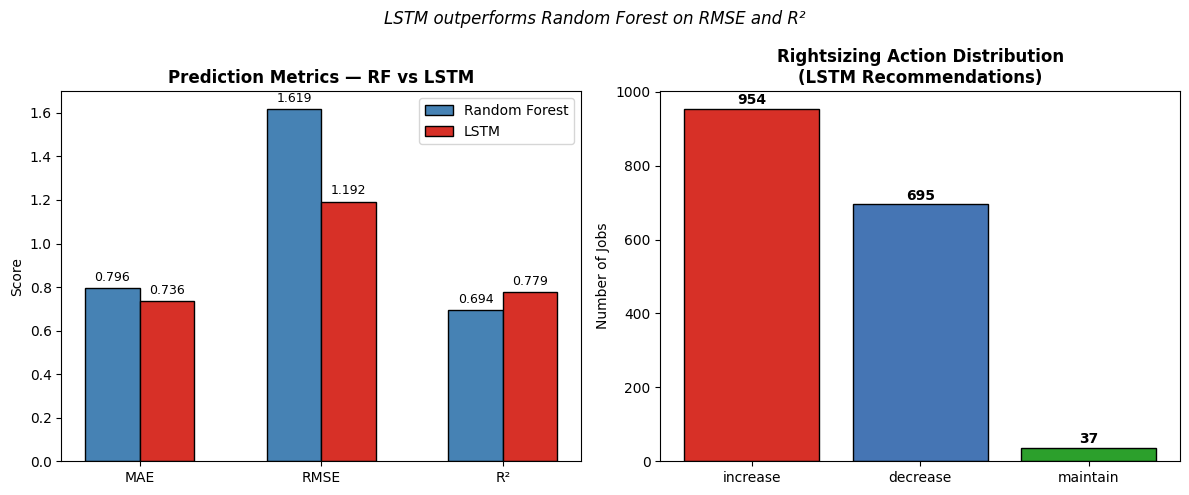

In [18]:
print("=" * 60)
print("LSTM vs RANDOM FOREST BASELINE COMPARISON")
print("=" * 60)

print(f"""
Target: cpu_max_peak prediction (peak CPU usage per job)

{'Metric':<15} {'Random Forest':>15} {'LSTM':>15}
{'-'*45}
{'MAE':<15} {'0.796':>15} {mae:>15.3f}
{'RMSE':<15} {'1.619':>15} {rmse:>15.3f}
{'R²':<15} {'0.694':>15} {r2:>15.3f}

Key differences:
  Random Forest uses job-level metadata (plan_cpu, instance_count, etc.)
  LSTM uses the actual sequence of cpu_max readings per job

  RF was trained on under-provisioned jobs only.
  LSTM is trained on all jobs — it learns from the full range of
  usage patterns across the cluster.
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics   = ['MAE', 'RMSE', 'R²']
rf_vals   = [0.796, 1.619, 0.694]
lstm_vals = [mae, rmse, r2]

x = np.arange(len(metrics))
w = 0.3

axes[0].bar(x - w/2, rf_vals,   w, label='Random Forest',
            color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, lstm_vals, w, label='LSTM',
            color='#d73027', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Prediction Metrics — RF vs LSTM', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.3f', fontsize=9, padding=3)

actions      = ['increase', 'decrease', 'maintain']
action_counts = test_jobs['action'].value_counts()
counts = [action_counts.get(a, 0) for a in actions]
colors = ['#d73027', '#4575b4', '#2ca02c']

axes[1].bar(actions, counts, color=colors, edgecolor='black')
axes[1].set_title('Rightsizing Action Distribution\n(LSTM Recommendations)', fontweight='bold')
axes[1].set_ylabel('Number of Jobs')
for bar, count in zip(axes[1].patches, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('LSTM outperforms Random Forest on RMSE and R²',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()